In [49]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler 
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import classification_report, confusion_matrix ,accuracy_score 
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
df = pd.read_csv("loan_approval_dataset.csv")

In [51]:
df

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


In [52]:
df.columns = df.columns.str.strip()
df = df.drop(columns=["loan_id"])

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   no_of_dependents          4269 non-null   int64 
 1   education                 4269 non-null   object
 2   self_employed             4269 non-null   object
 3   income_annum              4269 non-null   int64 
 4   loan_amount               4269 non-null   int64 
 5   loan_term                 4269 non-null   int64 
 6   cibil_score               4269 non-null   int64 
 7   residential_assets_value  4269 non-null   int64 
 8   commercial_assets_value   4269 non-null   int64 
 9   luxury_assets_value       4269 non-null   int64 
 10  bank_asset_value          4269 non-null   int64 
 11  loan_status               4269 non-null   object
dtypes: int64(9), object(3)
memory usage: 400.3+ KB


In [54]:
df.isnull().sum()

no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

In [55]:
le = LabelEncoder()
df["education"] = le.fit_transform(df["education"])          
df["self_employed"] = le.fit_transform(df["self_employed"])  
df["loan_status"] = le.fit_transform(df["loan_status"]) 

In [56]:
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0
1,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1
2,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1
3,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1
4,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1


ERROR:asyncio:Task exception was never retrieved
future: <Task finished name='Task-31' coro=<Server.serve() done, defined at c:\Users\dell\anaconda3\Lib\site-packages\uvicorn\server.py:68> exception=KeyboardInterrupt()>
Traceback (most recent call last):
  File "c:\Users\dell\anaconda3\Lib\site-packages\uvicorn\main.py", line 579, in run
    server.run()
  File "c:\Users\dell\anaconda3\Lib\site-packages\uvicorn\server.py", line 66, in run
    return asyncio.run(self.serve(sockets=sockets))
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\dell\anaconda3\Lib\site-packages\nest_asyncio.py", line 30, in run
    return loop.run_until_complete(task)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\dell\anaconda3\Lib\site-packages\nest_asyncio.py", line 92, in run_until_complete
    self._run_once()
  File "c:\Users\dell\anaconda3\Lib\site-packages\nest_asyncio.py", line 133, in _run_once
    handle._run()
  File "c:\Users\dell\anaconda3\Lib\asyncio\events.py", li

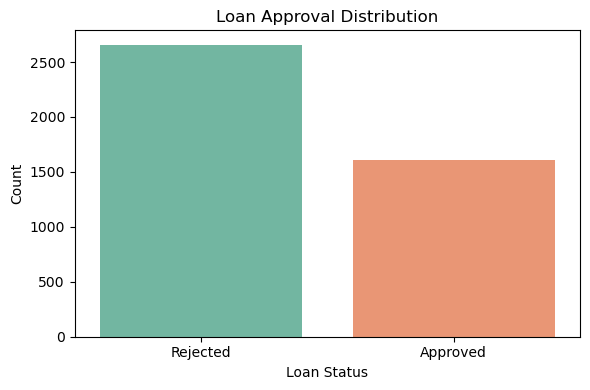

In [57]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='loan_status', palette='Set2')
plt.title("Loan Approval Distribution")
plt.xticks([0, 1], ['Rejected', 'Approved'])
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

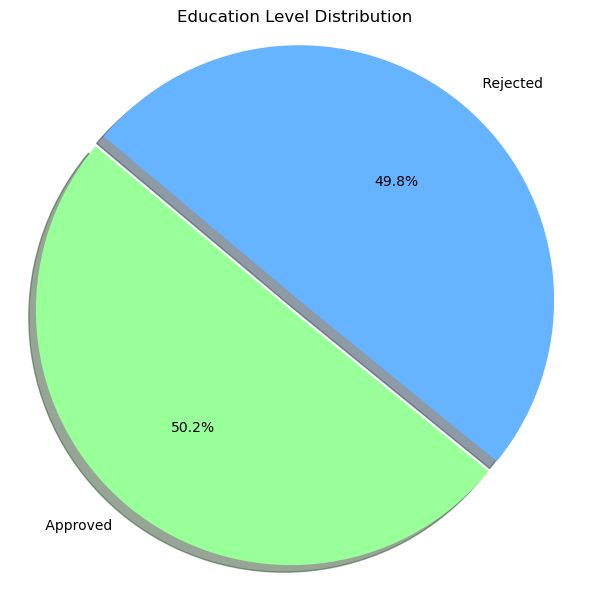

In [58]:
education_labels = le.classes_  # ['Graduate', 'Not Graduate']
education_counts = df["education"].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(
    education_counts,
    labels=education_labels,
    autopct="%1.1f%%",
    startangle=140,
    explode=(0.05, 0),
    shadow=True,
    colors=["#99ff99", "#66b3ff"]
)
plt.title("Education Level Distribution")
plt.axis("equal")
plt.tight_layout()
plt.show()

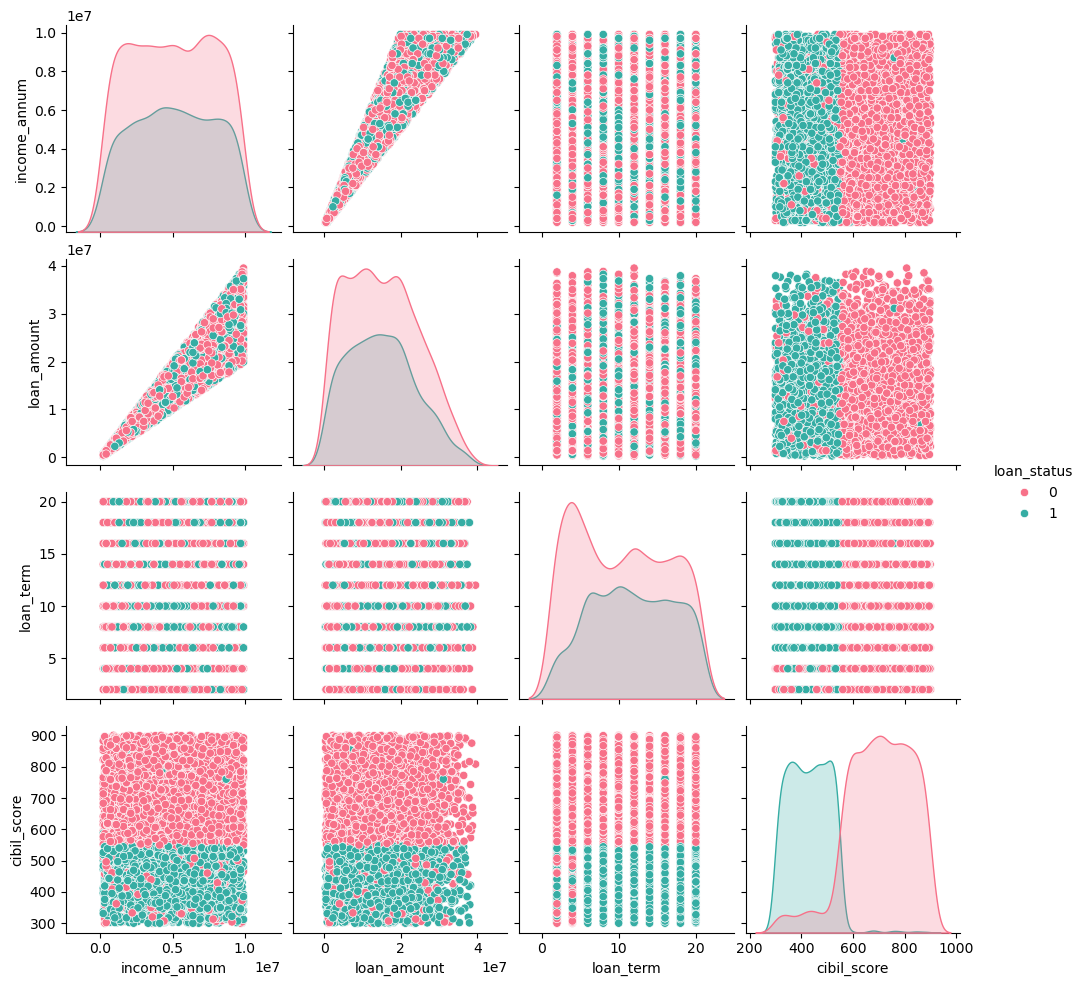

In [59]:
selected_features = ["income_annum", "loan_amount", "loan_term", "cibil_score", "loan_status"]
sns.pairplot(df[selected_features], hue="loan_status", palette='husl')
plt.show()

In [60]:
selected_features = ["income_annum", "loan_amount", "loan_term", "cibil_score", "education", "self_employed"]
X = df[selected_features]
y = df["loan_status"]


In [61]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [62]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [63]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

In [64]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 97.54%


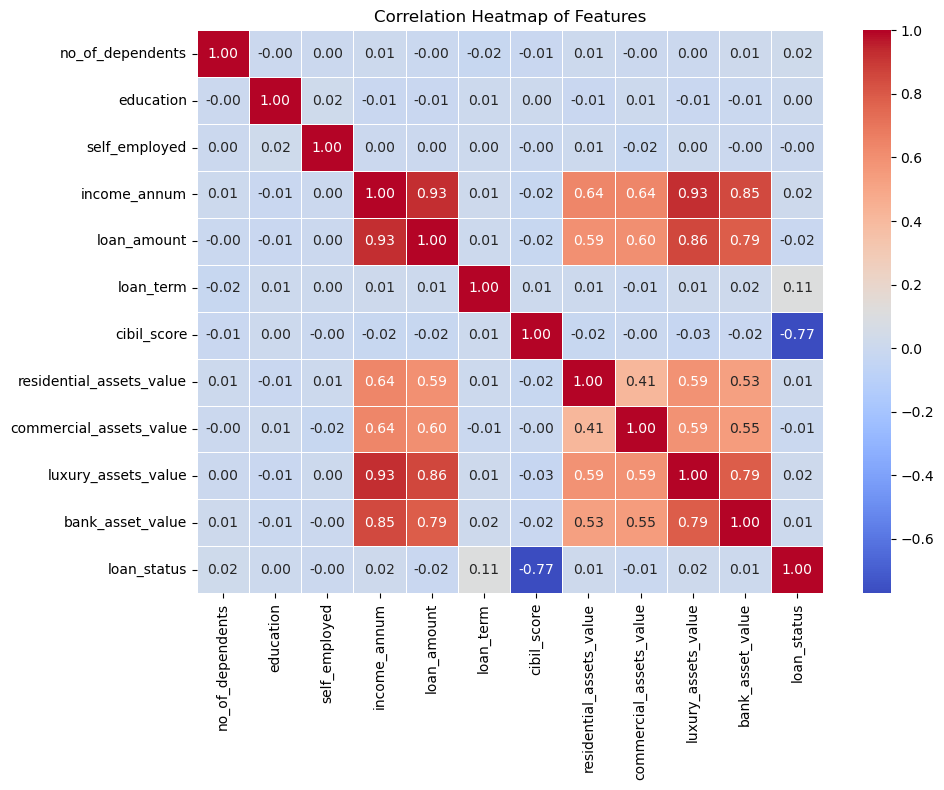

In [65]:
plt.figure(figsize=(10, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5, fmt=".2f")
plt.title("Correlation Heatmap of Features")
plt.tight_layout()
plt.show()


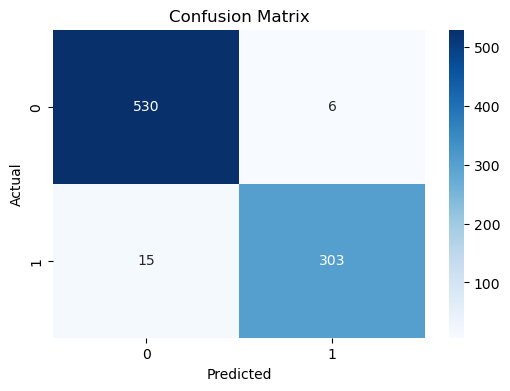

In [66]:
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [67]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       536
           1       0.98      0.95      0.97       318

    accuracy                           0.98       854
   macro avg       0.98      0.97      0.97       854
weighted avg       0.98      0.98      0.98       854



C:\Users\dell\AppData\Local\Temp\ipykernel_23168\2883897072.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance, y=feature_importance.index, palette='viridis')


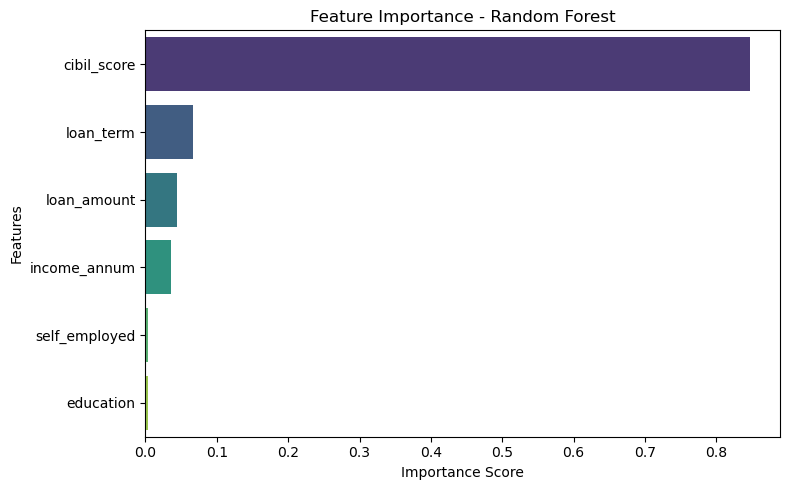

In [68]:
feature_importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x=feature_importance, y=feature_importance.index, palette='viridis')
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

In [69]:
import pickle

with open("loan_model.pkl", "wb") as f:
    pickle.dump(model, f)

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)


In [ ]:
from fastapi import FastAPI, HTTPException
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel
import numpy as np
import joblib
from pathlib import Path

app = FastAPI()

# Allow CORS for the React app running on localhost:5174
app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],  # Allow your React app's URL
    allow_credentials=True,
    allow_methods=["*"],  # Allow all HTTP methods
    allow_headers=["*"],  # Allow all headers
)

# Path for model artifacts
MODEL_DIR = "model_artifacts"
Path(MODEL_DIR).mkdir(exist_ok=True)

# Load preprocessing and model artifacts
try:
    model = joblib.load(f"{MODEL_DIR}/model.pkl")
    scaler = joblib.load(f"{MODEL_DIR}/scaler.pkl")
    le_education = joblib.load(f"{MODEL_DIR}/le_education.pkl")
    le_self_employed = joblib.load(f"{MODEL_DIR}/le_self_employed.pkl")
    le_loan_status = joblib.load(f"{MODEL_DIR}/le_loan_status.pkl")
except FileNotFoundError:
    raise Exception("Model artifacts not found. Please train and save the model first.")

class LoanRequest(BaseModel):
    income_annum: float
    loan_amount: float
    loan_term: int
    cibil_score: int
    education: str
    self_employed: str

@app.post("/loan_predict")
async def loan_predict(data: LoanRequest):
    try:
        # Clean inputs
        education_clean = data.education.strip()
        self_employed_clean = data.self_employed.strip()

        # Validate categorical inputs
        if education_clean not in le_education.classes_:
            raise HTTPException(
                status_code=400,
                detail=f"Invalid education value. Must be one of: {list(le_education.classes_)}"
            )
        if self_employed_clean not in le_self_employed.classes_:
            raise HTTPException(
                status_code=400,
                detail=f"Invalid self_employed value. Must be one of: {list(le_self_employed.classes_)}"
            )

        # Encode categorical variables
        education_encoded = le_education.transform([education_clean])[0]
        self_employed_encoded = le_self_employed.transform([self_employed_clean])[0]

        # Construct features array in correct order
        features = np.array([[
            data.income_annum,
            data.loan_amount,
            data.loan_term,
            data.cibil_score,
            education_encoded,
            self_employed_encoded
        ]])

        # Scale features using the loaded scaler
        features_scaled = scaler.transform(features)

        # Predict with the loaded model
        prediction_encoded = model.predict(features_scaled)[0]

        # Decode prediction back to original label
        prediction_label = le_loan_status.inverse_transform([prediction_encoded])[0]

        return {"loan_status_prediction": prediction_label}

    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))

# For development use only
if __name__ == "__main__":
    import uvicorn
    import nest_asyncio
    nest_asyncio.apply()
    uvicorn.run(app, host="0.0.0.0", port=8003)


INFO:     Started server process [13392]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8003 (Press CTRL+C to quit)


INFO:     127.0.0.1:61247 - "OPTIONS /loan_predict HTTP/1.1" 200 OK
INFO:     127.0.0.1:61247 - "POST /loan_predict HTTP/1.1" 200 OK


c:\Users\dell\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


INFO:     127.0.0.1:61250 - "POST /loan_predict HTTP/1.1" 200 OK


c:\Users\dell\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


...

c:\Users\dell\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


INFO:     127.0.0.1:64598 - "POST /loan_predict HTTP/1.1" 200 OK


c:\Users\dell\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


INFO:     127.0.0.1:64881 - "POST /loan_predict HTTP/1.1" 200 OK


c:\Users\dell\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
